<a href="https://colab.research.google.com/github/olorunfemibabalola/Research-Methods-DSAI/blob/main/2405025Lab_7_RMDSAI_Activity_2_Copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Activity-2: Building a CNN for an Image Classification Problem**

In this lab, a CNN will be trained on an image dataset from PyTorch (that is, the framework provides the dataset).

# **Dataset:**
The dataset to be used is CIFAR10, which contains a total of 60,000 images of vehicles and animals. There are 10 different class labels (such as "airplane," "bird," "automobile," "cat," and so on). The training set contains 50,000 images, while the testing set contains the remaining 10,000.

# **Note**
To explore this dataset even further, visit the following URL:
https://www.cs.toronto.edu/~kriz/cifar.html

# **Scenario:**

You work at an artificial intelligence company that develops custom-made models for the needs of its customers. Your team is currently creating a model that can differentiate a picture of a vehicle from that of an animal
and, more specifically, that can recognize different kinds of animals and different types of vehicles. They have provided you with a dataset containing 60,000 images to build the model.


# **Note:**

Make sure you have selected GPU as runtime type. Running the code on CPU may take a long time.

# **Tasks**

Task-1: Import the required libraries.

In [6]:
#write your code
import numpy as np
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

Task-2: Set the transformations to be performed on the data, which will be the conversion of the data into tensors and the normalization of the pixel values.

In [7]:
#write your code
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])





Task-3: Set a batch size of 100 images and download both the training and testing data from the CIFAR10 dataset.

In [8]:
#write your code
batch_size = 100

train_data = datasets.CIFAR10('data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10('data', train=False, download=True, transform=transform)

Task-4: Using a validation size of 20%, define the training and validation sampler that will be used to divide the dataset into those two sets.

In [9]:
#write your code
dev_size = 0.2
idx = list(range(len(train_data)))
np.random.shuffle(idx)

split_size = int(np.floor(dev_size * len(train_data)))
train_idx, dev_idx = idx[split_size:], idx[:split_size]

train_sampler = SubsetRandomSampler(train_idx)
dev_sampler = SubsetRandomSampler(dev_idx)

Task-5: Use the DataLoader() function to define the batches to be used for each setof data.

In [10]:
#write your code

train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=train_sampler)
dev_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, sampler=dev_sampler)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)


Task-6: Define the architecture of your network. Use the following information to do so:
- Conv1: A convolutional layer that takes the colored image as input and passes it through 10 filters of size 3. Both the padding and the stride should be set to 1.
- Conv2: A convolutional layer that passes the input data through 20 filters of size 3. Both the padding and the stride should be set to 1.
- Conv3: A convolutional layer that passes the input data through 40 filters of size 3. Both the padding and the stride should be set to 1.
- Use the ReLU activation function after each convolutional layer.
- A pooling layer after each convolutional layer, with a filter size and stride of 2.
- A dropout term set to 20% after flattening the image.
- Linear1: A fully connected layer that receives the flattened matrix from the
previous layer as input and generates an output of 100 units. Use the ReLU
activation function for this layer. Here, the dropout term is set to 20%.
- Linear2: A fully connected layer that generates 10 outputs, one for each class label. Use the log_softmax activation function for the output layer.

In [11]:
#write your code
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 10, 3, 1, 1)
        self.conv2 = nn.Conv2d(10, 20, 3, 1, 1)
        self.conv3 = nn.Conv2d(20, 40, 3, 1, 1)
        self.pool = nn.MaxPool2d(2, 2)

        self.linear1 = nn.Linear(40 * 4 * 4, 100)
        self.linear2 = nn.Linear(100, 10)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))


        x = x.view(-1, 40 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.linear1(x))
        x = self.dropout(x)
        x = F.log_softmax(self.linear2(x), dim=1)

        return x


# Now, Add the code to view the CNN architecture

In [12]:
#write your code

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(20, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear1): Linear(in_features=640, out_features=100, bias=True)
  (linear2): Linear(in_features=100, out_features=10, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
)


Task-7: Define all of the parameters that are required to train your model. Set the number of epochs to 50.

In [13]:
#write your code

model = CNN().to("cuda")
loss_function = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

Task-8: Train your network and be sure to save the values for the loss and accuracy of both the training and validation sets.

In [14]:
train_losses, dev_losses, train_acc, dev_acc= [], [], [], []
x_axis = []
for e in range(1, epochs+1):
    losses = 0
    acc = 0
    iterations = 0
    model.train()
    for data, target in train_loader:
        iterations += 1
        pred = model(data.to("cuda"))
        loss = loss_function(pred, target.to("cuda"))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses += loss.item()
        p = torch.exp(pred)
        top_p, top_class = p.topk(1, dim=1)
        acc += accuracy_score(target.to("cpu"), top_class.to("cpu"))

    dev_losss = 0
    dev_accs = 0
    iter_2 = 0

    if e%5 == 0 or e == 1:
        x_axis.append(e)

        with torch.no_grad():
            model.eval()

            for data_dev, target_dev in dev_loader:
                iter_2 += 1

                dev_pred = model(data_dev.to("cuda"))
                dev_loss = loss_function(dev_pred, target_dev.to("cuda"))
                dev_losss += dev_loss.item()

                dev_p = torch.exp(dev_pred)
                top_p, dev_top_class = dev_p.topk(1, dim=1)
                dev_accs += accuracy_score(target_dev.to("cpu"), dev_top_class.to("cpu"))

        train_losses.append(losses/iterations)
        dev_losses.append(dev_losss/iter_2)
        train_acc.append(acc/iterations)
        dev_acc.append(dev_accs/iter_2)

        print("Epoch: {}/{}.. ".format(e, epochs),
              "Training Loss: {:.3f}.. ".format(losses/iterations),
              "Validation Loss: {:.3f}.. ".format(dev_losss/iter_2),
              "Training Accuracy: {:.3f}.. ".format(acc/iterations),
              "Validation Accuracy: {:.3f}".format(dev_accs/iter_2))

Epoch: 1/50..  Training Loss: 1.755..  Validation Loss: 1.502..  Training Accuracy: 0.359..  Validation Accuracy: 0.455
Epoch: 5/50..  Training Loss: 1.206..  Validation Loss: 1.093..  Training Accuracy: 0.567..  Validation Accuracy: 0.615
Epoch: 10/50..  Training Loss: 0.986..  Validation Loss: 0.931..  Training Accuracy: 0.648..  Validation Accuracy: 0.674
Epoch: 15/50..  Training Loss: 0.882..  Validation Loss: 0.858..  Training Accuracy: 0.687..  Validation Accuracy: 0.702
Epoch: 20/50..  Training Loss: 0.805..  Validation Loss: 0.833..  Training Accuracy: 0.712..  Validation Accuracy: 0.711
Epoch: 25/50..  Training Loss: 0.748..  Validation Loss: 0.812..  Training Accuracy: 0.733..  Validation Accuracy: 0.721
Epoch: 30/50..  Training Loss: 0.706..  Validation Loss: 0.806..  Training Accuracy: 0.745..  Validation Accuracy: 0.723
Epoch: 35/50..  Training Loss: 0.667..  Validation Loss: 0.792..  Training Accuracy: 0.760..  Validation Accuracy: 0.731
Epoch: 40/50..  Training Loss: 0.6

Task-9: Plot the loss and accuracy of both sets.

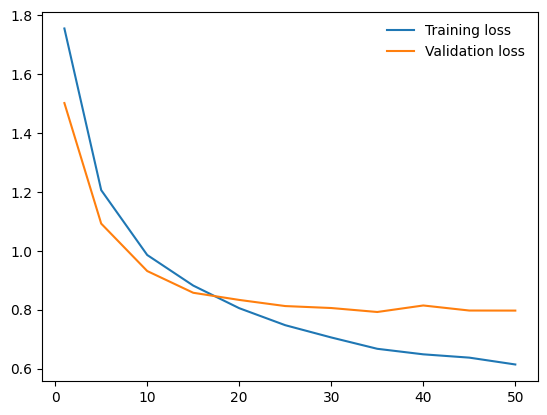

In [15]:
plt.plot(x_axis,train_losses, label='Training loss')
plt.plot(x_axis, dev_losses, label='Validation loss')
plt.legend(frameon=False)
plt.show()

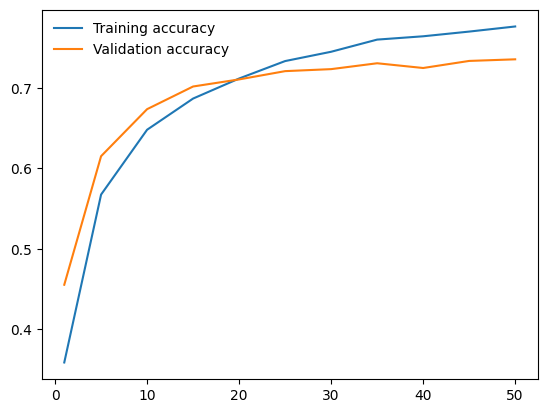

In [16]:
plt.plot(x_axis, train_acc, label="Training accuracy")
plt.plot(x_axis, dev_acc, label="Validation accuracy")
plt.legend(frameon=False)
plt.show()

Task-10: Check the model's accuracy on the testing set—it should be around 72%.

In [17]:
model.eval()
iter_3 = 0
acc_test = 0
for data_test, target_test in test_loader:
    iter_3 += 1
    test_pred = model(data_test.to("cuda"))
    test_pred = torch.exp(test_pred)
    top_p, top_class_test = test_pred.topk(1, dim=1)
    acc_test += accuracy_score(target_test.to("cpu"), top_class_test.to("cpu"))
print(acc_test/iter_3)

0.7211
